# Exploración inicial de datos

Dataset: `data/dataset.csv` (Give Me Some Credit — riesgo de incumplimiento crediticio).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/dataset.csv")
df.shape

(150000, 12)

## Vista general

In [5]:
df.head()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


## Valores nulos y duplicados

In [8]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
pd.DataFrame({"nulos": nulos, "% nulos": pct_nulos}).query("nulos > 0")

,nulos,% nulos
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


In [9]:
df.duplicated().sum()

np.int64(0)

## Variable objetivo: `SeriousDlqin2yrs`

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


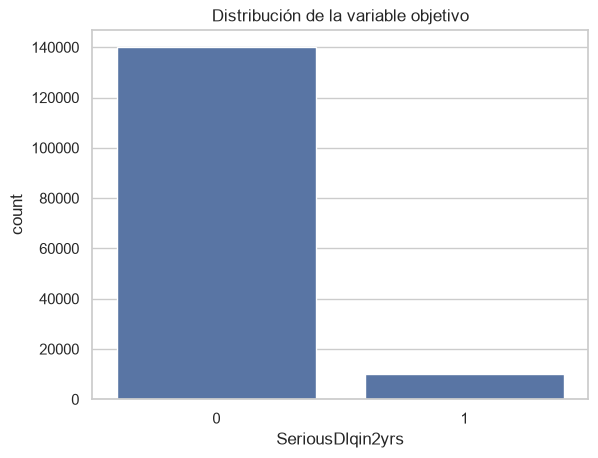

In [10]:
target = "SeriousDlqin2yrs"
conteo = df[target].value_counts(normalize=True) * 100
print(conteo)

sns.countplot(data=df, x=target)
plt.title("Distribución de la variable objetivo")
plt.show()

## Distribución de variables numéricas

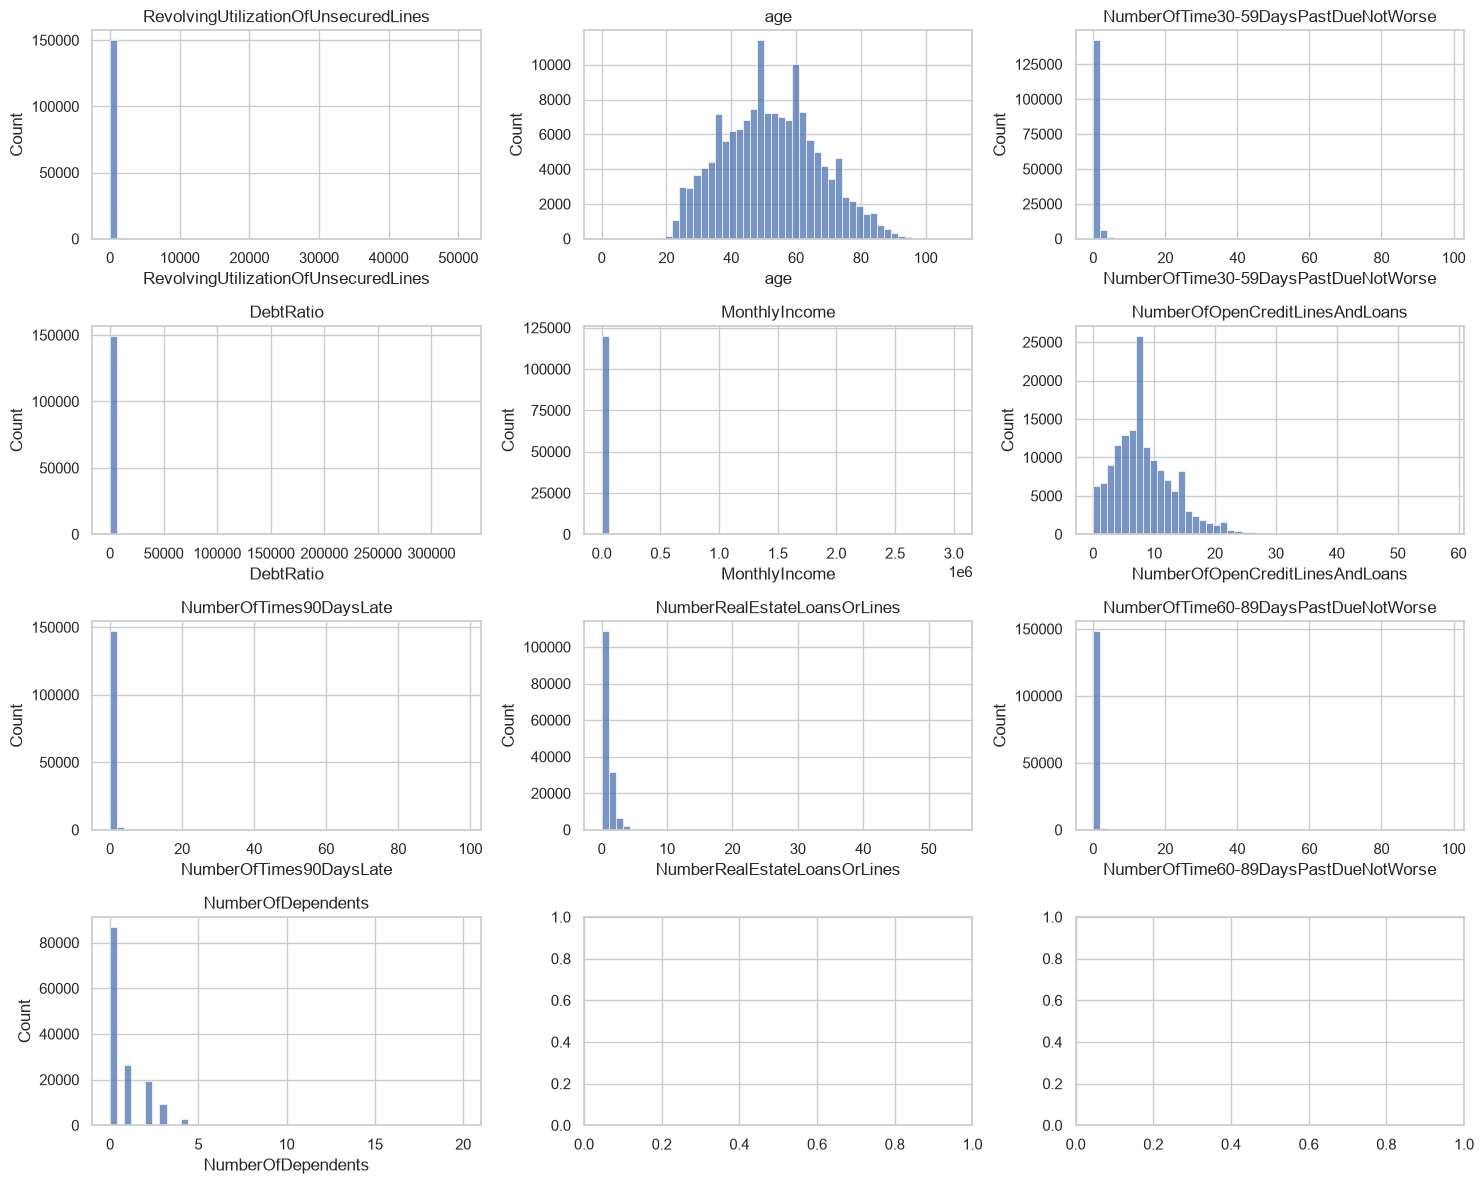

In [11]:
num_cols = [c for c in df.columns if c not in ["Id", target]]

fig, axes = plt.subplots(nrows=(len(num_cols) + 2) // 3, ncols=3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Outliers (boxplots)

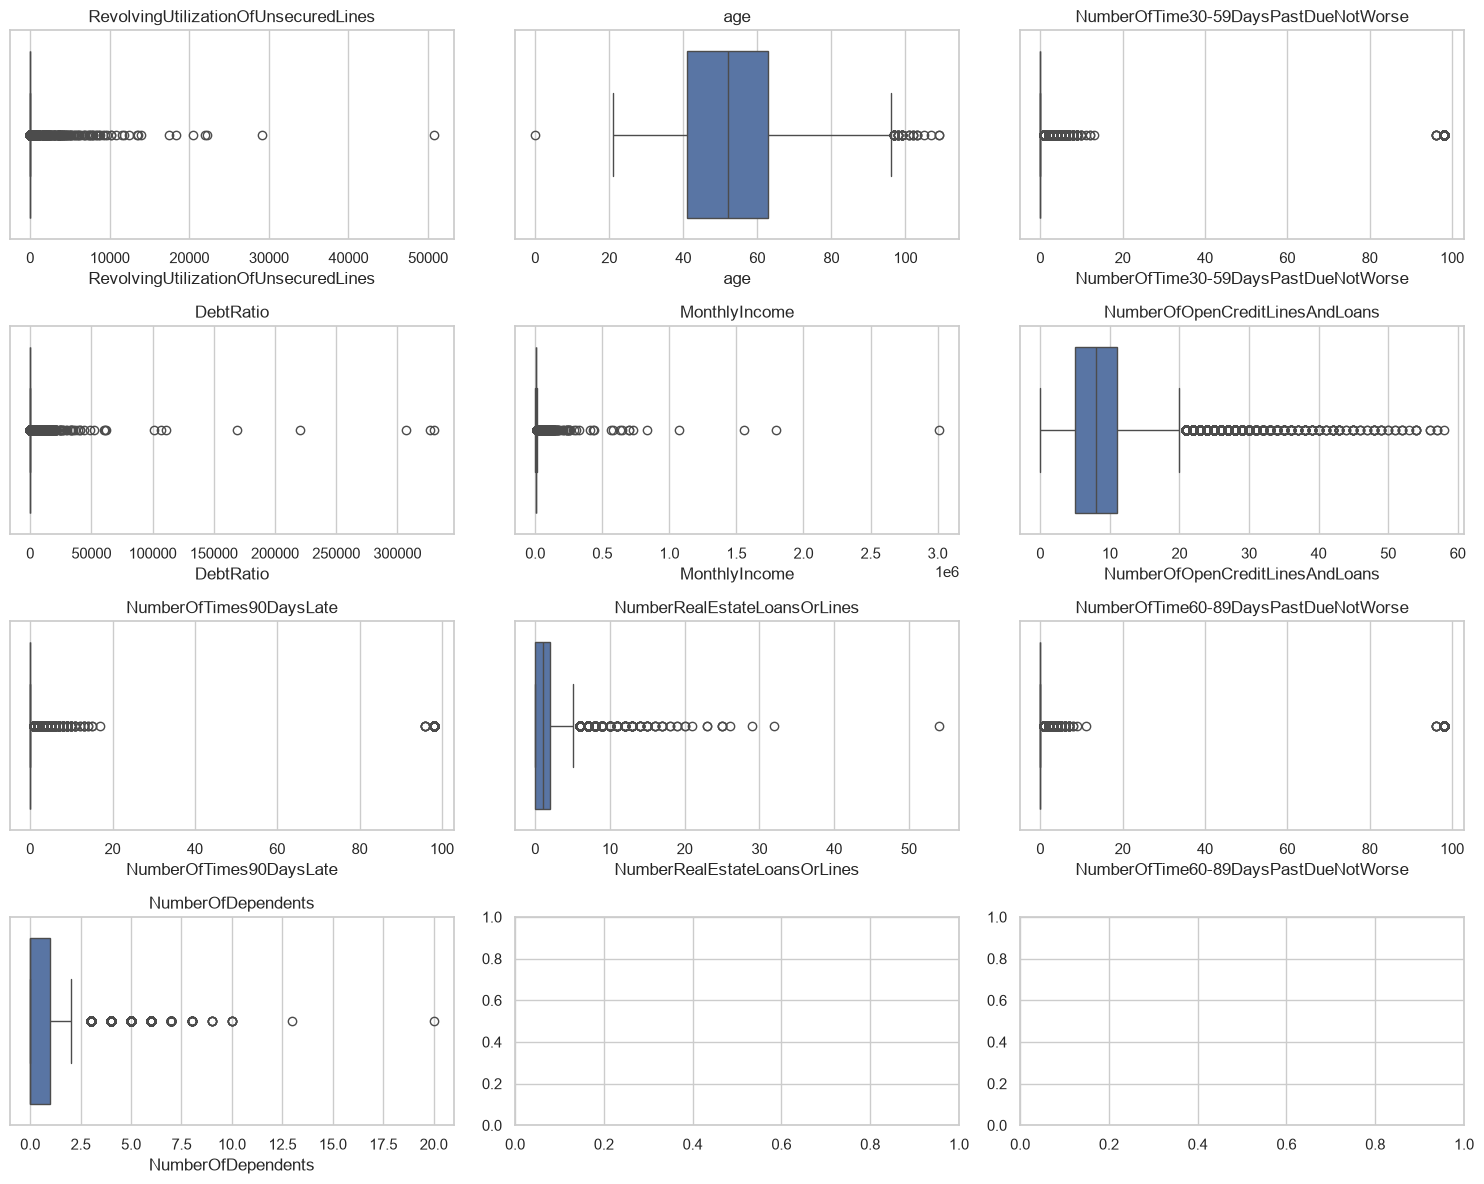

In [12]:
fig, axes = plt.subplots(nrows=(len(num_cols) + 2) // 3, ncols=3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Correlaciones

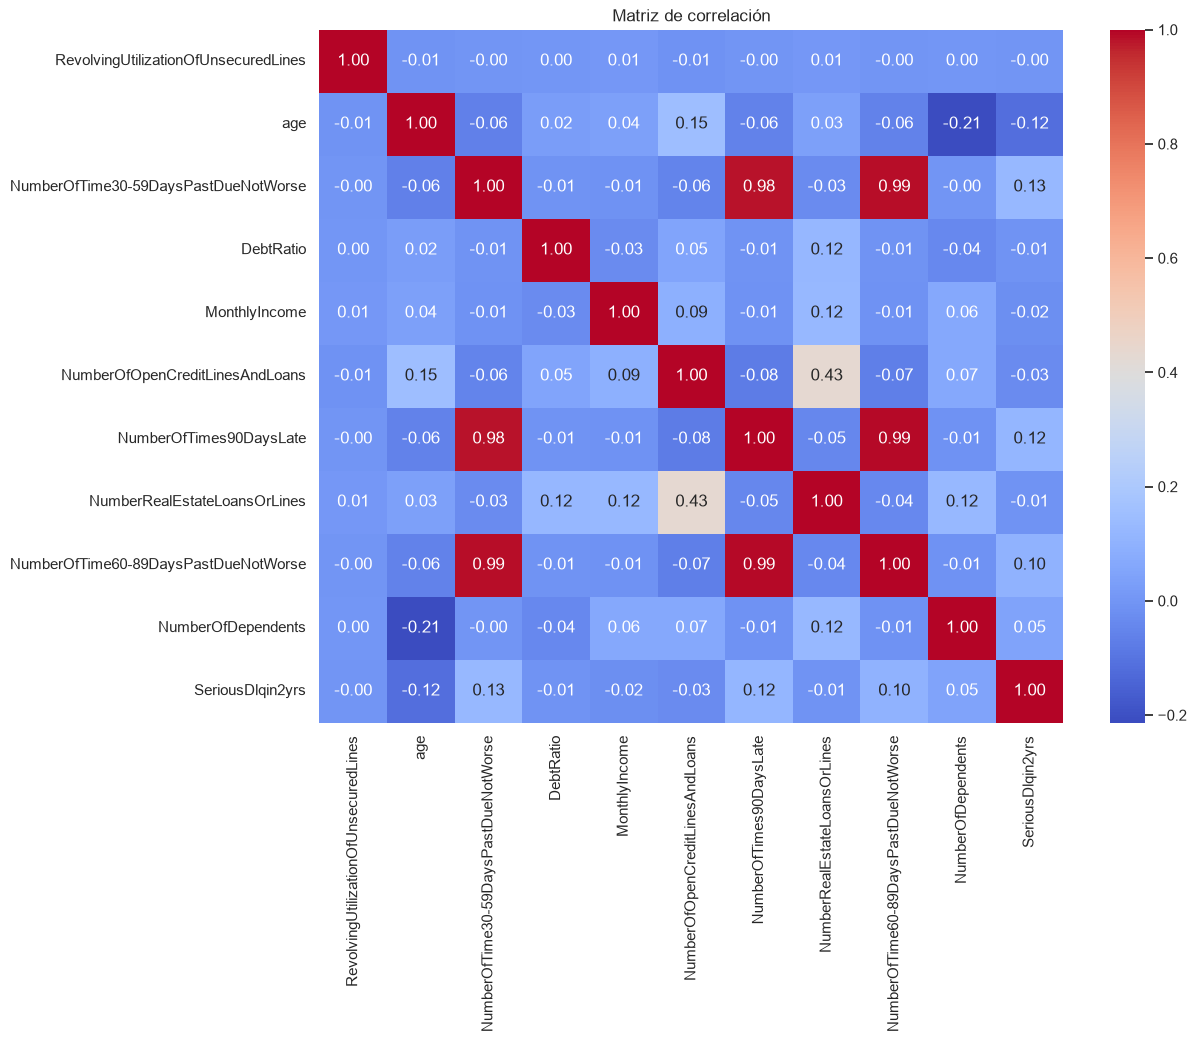

In [13]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[num_cols + [target]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## Notas / hallazgos

- 
- 
- 